# Lab 04: Linear programming in telecommunications



## software LPSolve


> LP Solve was introduced during the lectures. The program requires us to correctly formulate the criteria 
function (min / max), constraints and variable declaration. The program then solves the problem and 
presents us with the possible solutions. 

> LPSolve is available for download here:

https://sourceforge.net/projects/lpsolve/

## Example 1: Small problem

Consider the following linear programming problem:

Maximize $ z = x + 2y $,

Subject to: 
* $2x + y \le 20$
* $-4x + 5y \le 10$
* $-x + 2y \ge -2 $
* $ x \ge 0$
* $ y \ge 0$


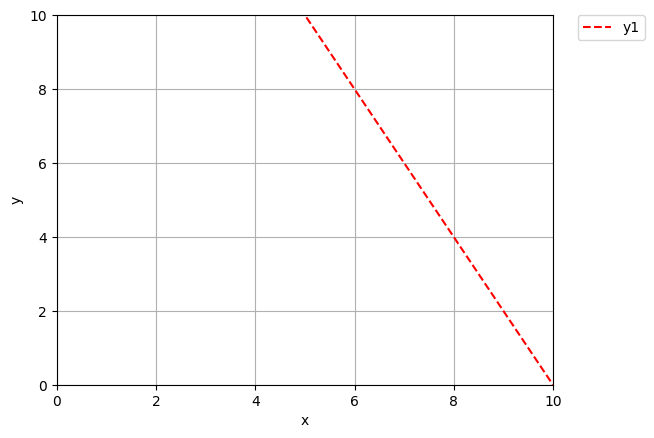

In [6]:
# 2.1
# Plot the constraints > Feasible region

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from IPython.display import Image

x = np.linspace(0, 10, 100)

# Constraints
y1 = 20- 2*x
y2 = (10+4*x)/5
y3 = (x-2)/2
ymax = np.linspace(10,10,100)

# kriterij y
z_const = 3
y_crit = (z_const - x )/2.0

# Make plot
plt.plot( x, y1, 'r--', label='y1'  )


plt.xlim((0, 10))
plt.ylim((0, 10))
plt.xlabel('x')
plt.ylabel('y')


#plt.fill_between(x, y1, color='red', alpha=0.2)
#plt.fill_between(x, y2, color='blue', alpha=0.2)
#plt.fill_between(x, y3, ymax, color='green', alpha=0.2)


plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid()
plt.show()



### Solving with scipy linprog

Equivalent problem using minimization

Minimize $ -z = -x - 2y $, 

Subject to: 
* $2x + y \le 20$
* $-4x + 5y \le 10$
* $x - 2y \le 2 $ , 
* $ x \ge 0$
* $ y \ge 0$


https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html


In [ ]:
# 2.2
# Define objective function
objective = [-3, -1]
# Define inequality constraints
lhs_ineq = [[2,1],
            [-4,5],
            [1,-2]]     # left hand side coefficients
rhs_ineq = [20,10,2]                # Right hand side values

# Bounds / meje
bnd = [(0, float("inf")),  # Bounds of x
        (0, float("inf"))]  # Bounds of y

# Optimize
from scipy.optimize import linprog

opt = linprog(c=objective, A_ub=lhs_ineq, b_ub=rhs_ineq,
               bounds=bnd,
               method="revised simplex")

print(opt)



 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -28.400000000000002
       x: [ 8.400e+00  3.200e+00]
     nit: 2


In [4]:
# Plot the solution 



In [10]:
# 2.3 Change criterion and find new solution



## 2. Software LPSolve

> LP Solve was introduced during the lectures. The program requires us to correctly formulate the criteria 
function (min / max), constraints and variable declaration. The program then solves the problem and 
presents us with the possible solutions. 

> LPSolve is available for download here:

https://sourceforge.net/projects/lpsolve/

## 3.1 
> Example 1: Optimal number of subscribers

> Task: Based on the problem description, we derive optimization criteria and constraints, and 
> solve problem using the LPSolve software.

> Problem 1 description:

> A new mobile service provider is entering the market. Since it does not yet have it’s own infrastructure it  
>decided to lease capacities from an existing provider. The provider leased 1000 SMS / month and 2000 minutes / month.
> The service provider will offer a package for personal use costing 20€ / month and a business package costing 40€ / month.
> Preliminary market research shows that a typical user sends 40 SMS each month and talks for 20 minutes while business 
>users send 10 SMS and spend 50 minutes.
>
> Task: Calculate, how many of each type of packages must the provider sell in order to earn maximum profit, 
>given the available leased capacities.                                    
   

### Formulate a problem in LPSolve
> How to use LPSolve for solving this problem.

 We have the following variables:
* Number of subscribers, persons :  n_pers
* Number of subscribers, business users:  n_b. 

> We optimize criterion, which is maximum revenue from selling subscriptions, given that the cost is 20 for persons and 40 for companies. 

<code>/* Objective function */ <br>
max: + 20 n_pers + 40 n_b;  </code>

> We need to define bounds (constraints) according to the number of leased resources (1000 SMS, 2000 minutes)

<code> /* Variable bounds */ <br>
  40 n_pers + 10 n_b <= 1000; 
  20 n_pers + 50 n_b <= 2000; </code>

> The variables (numbers of packages) are integers:

<code> int n_pers, n_b; </code>


### 3.1 Task 1

Find a solution using LpSolve.


### Problem visualization (Additional task)

> Visualization of the problem and finding a graphical solution. By using matplotlib we will produce graph showing the solution 
> space and variable bounds.

Text(0, 0.5, 'n_p')

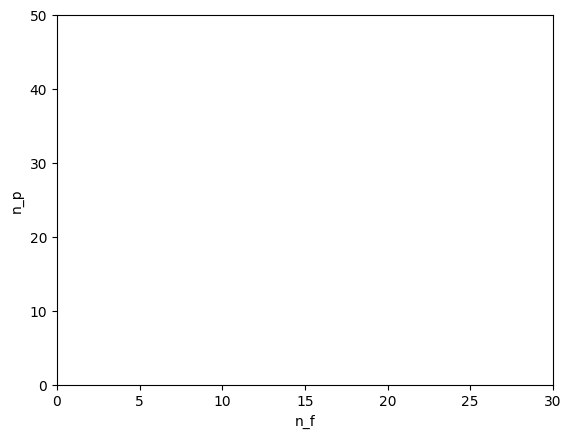

In [6]:
n_f = np.linspace(0, 30, 100)

# Write Constraints
#n_p1
#n_p2

# Write criterion line
income = 1660
#npk 

# Make plot
#plt.plot( n_f, n_p1, 'r--', label='sms'  )
#plt.plot(n_f, n_p2, 'b--', label='minutes')
#plt.plot(n_f, npk, 'g--', label='criterion')

plt.xlim((0, 30))
plt.ylim((0, 50))
plt.xlabel('n_f')
plt.ylabel('n_p')

#plt.fill_between(n_f, n_p1, color='red', alpha=0.2)
#plt.fill_between(n_f, n_p2, color='blue', alpha=0.2)
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
#plt.grid()
#plt.show()


### Slack variables


>The use of slack variables enables us to redefine constraints from previous examples. While this means introducing 
>as many new variables as there are constraints, the benefits outweigh the cost. Solving such a problem 
>provides us with additional data about the solution - how far is the solution from reaching the actual constraint. 
>Using the first example the mobile service provider can gain information on how much of the leased capacities (sms, minutes) remain free 
>after reaching the optimal number of subscribers. 

### 3.2 Slack variables


> Task 1: Define and use slack variables s_sms and s_min to find out about the remaining resouces. Example: 
 
>> 40 n_pers + 10 n_b + s_sms = 1000; 
 

## 3.4 Example 2: Finding shortes path in a network graph   



> Finding a shortest path in a graph can also be defined as a LP problem. 

In [12]:
#from IPython.display import Image
#Image("Omrezje.png")

![Graf](Omrezje2022.png "Graf omrežja")

<b>Problem statement:</b>

> We need to find shortest path from node A to node H. We will define binary variables (0,1) whose value defines if the connection is part 
>of the shortest path.  

<code>bin ab, ac .... ;</code> 

> Criterion function is a minimum of sum of all included links

<code>min: + 42 ab + 7 ac + 18 ad + ......; </code>

> Constraints need to be defined for each node. For node A, the sum of connections is 1: 

<code> +ab + ac + ad = 1;</code>

For other nodes, however, it is true that we write + and - according to the directions of the arrows (paths), and the sum must be 0 (after one connection we arrive, after the other we go).
In the last one, the sum is -1. 

<code> -ab -bc -bf + bh = 0; </code>




###  Task 3:


> Tasks:
> * Write complete problem formulation in LPSolve IDE, and use LPSolve to find a solution. Describe the resulting shortest path.
> * Is there any other alternative solution (check the graph)?
> * Try to change a formulation to find a longest path. 
